## Set up and Imports

In [8]:
import os
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from google.colab import drive
from sklearn.model_selection import train_test_split
import torch
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.covariance import EmpiricalCovariance
from transformers import DataCollatorWithPadding
from sklearn.manifold import TSNE
import plotly.express as px
from sklearn.metrics import roc_curve

In [2]:
drive.mount('/content/drive')
SAVE_PATH = "/content/drive/MyDrive/SNIPS_OOD_Project"
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)

MODEL_NAME = "bert-base-uncased"
#MODEL_NAME = "distilbert-base-uncased"
NUM_FOLDS = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Mounted at /content/drive


## Metryki ODD

In [3]:
def compute_ood_metrics(logits, labels, ood_label_idx):
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()
    ood_scores = probs[:, ood_label_idx]
    y_true = (labels == ood_label_idx).astype(int)

    # AUROC
    auroc = roc_auc_score(y_true, ood_scores)
    # AUPR
    precision, recall, _ = precision_recall_curve(y_true, ood_scores)
    aupr = auc(recall, precision)
    # FPR95
    idx = np.argmin(np.abs(recall - 0.95))
    fpr95 = 1 - precision[idx]

    return auroc, aupr, fpr95

## SNIPS dataset

In [4]:
raw_ds = load_dataset("DeepPavlov/snips", "default")
train_df = pd.DataFrame(raw_ds['train'])
test_df = pd.DataFrame(raw_ds['test'])
snips_df = pd.concat([train_df, test_df], ignore_index=True) # Zawiera klasy 0-6

possible_text_cols = ['query', 'utterance', 'text', 'sentence']
for col in possible_text_cols:
    if col in snips_df.columns:
        snips_df = snips_df.rename(columns={col: 'text'})
        break

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/366k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/43.3k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/13084 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1400 [00:00<?, ? examples/s]

## Tokenizer and embeddings

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding=True,
        truncation=True,
        max_length=64
    )

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
def get_embeddings(model, dataset, batch_size=32):
    model.eval()
    model.to(device)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        collate_fn=data_collator
    )
    embs = []

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)

            embs.append(outputs.logits.detach().cpu().numpy())

    return np.concatenate(embs)

# WALIDACJA LEAVE-TWO-OUT (5 FOLDS)

## Cros-validation

In [7]:
FOLDS_CONFIG = [
    {"ood": [5, 6], "name": "Kino"},
    {"ood": [3, 0], "name": "Muzyka"},
    {"ood": [2, 1], "name": "Usługi"},
    {"ood": [4, 5], "name": "Twórczość"},
    {"ood": [6, 1], "name": "Mieszany"}
]

## Główna pętla - MAHALANOBIS

In [9]:
results_MAHALANOBIS = []

for fold_idx, config in enumerate(FOLDS_CONFIG):
    print(f"\n===== FOLD {fold_idx+1}: {config['name']} =====")

    ood_classes = config["ood"]
    id_classes = [c for c in range(7) if c not in ood_classes]

    id_df_full = snips_df[snips_df['label'].isin(id_classes)].copy()
    ood_df_full = snips_df[snips_df['label'].isin(ood_classes)].copy()

    train_id, test_id = train_test_split(
        id_df_full, test_size=0.2, stratify=id_df_full['label'], random_state=42
    )

    # ID train
    train_df_fold = train_id.copy()

    # TEST (zostaje RAW label, ale NIE mapujemy go do modelu)
    test_df_fold = pd.concat([test_id, ood_df_full]).sample(frac=1, random_state=42)

    # mapping tylko dla train
    mapping = {old_id: new_id for new_id, old_id in enumerate(id_classes)}

    train_df_fold["mapped_label"] = train_df_fold["label"].map(mapping)

    train_df_fold = train_df_fold.dropna(subset=["mapped_label"])
    train_df_fold["mapped_label"] = train_df_fold["mapped_label"].astype(int)

    # datasets
    train_ds = Dataset.from_pandas(
        train_df_fold[['text', 'mapped_label']].rename(columns={'mapped_label': 'label'})
    ).map(tokenize_fn, batched=True)

    test_ds = Dataset.from_pandas(test_df_fold).map(tokenize_fn, batched=True)

    train_ds = train_ds.remove_columns([col for col in train_ds.column_names if col not in ["input_ids", "attention_mask", "label"]])
    test_ds = test_ds.remove_columns([col for col in test_ds.column_names if col not in ["input_ids", "attention_mask"]])

    train_ds.set_format(type='torch')
    test_ds.set_format(type='torch')

    # model
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(id_classes)
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    training_args = TrainingArguments(
        output_dir="./tmp",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        eval_strategy="no",
        save_strategy="no",
        logging_steps=100,
        report_to="none",
        fp16=True
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        data_collator=data_collator
    )
    trainer.train()

    # EMBEDDINGI
    train_embeddings = get_embeddings(model, train_ds)
    test_embeddings = get_embeddings(model, test_ds)

    train_labels = train_df_fold['mapped_label'].values
    true_labels = test_df_fold['label'].values

    # MAHALANOBIS
    class_means = []
    for c in range(len(id_classes)):
        class_means.append(train_embeddings[train_labels == c].mean(axis=0))
    class_means = np.array(class_means)

    cov = EmpiricalCovariance().fit(train_embeddings)
    precision = cov.precision_

    def mahalanobis(x, mean):
        diff = x - mean
        return np.sqrt(diff @ precision @ diff.T)

    scores = []
    diff = test_embeddings[:, None, :] - class_means[None, :, :]
    scores = np.einsum('bij,jk,bik->bi', diff, precision, diff)
    scores = np.sqrt(scores).min(axis=1)

    scores = np.array(scores)

    # METRYKI
    y_true = np.array([1 if l in ood_classes else 0 for l in true_labels])

    auroc = roc_auc_score(y_true, scores)
    precision_arr, recall_arr, _ = precision_recall_curve(y_true, scores)
    aupr = auc(recall_arr, precision_arr)

    fpr, tpr, thresholds = roc_curve(y_true, scores)
    idx = np.argmin(np.abs(tpr - 0.95))
    fpr95 = fpr[idx]

    print(f"AUROC: {auroc:.4f}")

    results_MAHALANOBIS.append({
        "fold": fold_idx+1,
        "scenario": config['name'],
        "auroc": auroc,
        "aupr": aupr,
        "fpr95": fpr95
    })

    print(f"Generowanie wykresu t-SNE dla Foldu {fold_idx+1}...")

    # 1. Pobieramy testowe embeddingi i prawdziwe etykiety z tego foldu
    X_fold = test_embeddings

    # Przekształcamy etykiety liczbowe na czytelne nazwy (np. ID vs OOD)
    # Zmienna 'ood_classes' jest dostępna w pętli
    y_fold_names = []
    for label in true_labels:
        if label in ood_classes:
            y_fold_names.append(f"OOD (Klasa {label})")
        else:
            y_fold_names.append(f"ID (Klasa {label})")

    # 2. Obliczamy t-SNE
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    projections = tsne.fit_transform(X_fold)

    # 3. Tworzymy wykres
    fig = px.scatter(
        x=projections[:, 0],
        y=projections[:, 1],
        color=y_fold_names,
        title=f"Przestrzeń ukryta BERT - Fold {fold_idx+1}: {config['name']} (Zb. Testowy)",
        labels={'color': 'Rodzaj intencji', 'x': 'Wymiar 1', 'y': 'Wymiar 2'},
        opacity=0.8
    )

    # Pomniejszenie kropek dla lepszej czytelności
    fig.update_traces(marker=dict(size=4))

    # Wyświetlamy wykres
    # fig.show(renderer="colab")

    html_path = f"{SAVE_PATH}/mahalanobis_tsne_fold_{fold_idx+1}_base.html"
    fig.write_html(html_path)
    print(f"Zapisano wykres: {html_path}")


===== FOLD 1: Kino =====


Map:   0%|          | 0/8296 [00:00<?, ? examples/s]

Map:   0%|          | 0/6188 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Map:   0%|          | 0/6203 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.296029
200,0.048098
300,0.048538
400,0.015863
500,0.008913
600,0.003239
700,0.001682


AUROC: 0.8406
Generowanie wykresu t-SNE dla Foldu 5...
Zapisano wykres: /content/drive/MyDrive/SNIPS_OOD_Project/mahalanobis_tsne_fold_5_base.html


## Główna pętla - R-angle

In [10]:
results_RANGLE = []

for fold_idx, config in enumerate(FOLDS_CONFIG):
    print(f"\n===== FOLD {fold_idx+1}: {config['name']} =====")

    ood_classes = config["ood"]
    id_classes = [c for c in range(7) if c not in ood_classes]

    # PODZIAŁ DANYCH
    id_df_full = snips_df[snips_df['label'].isin(id_classes)].copy()
    ood_df_full = snips_df[snips_df['label'].isin(ood_classes)].copy()

    train_id, test_id = train_test_split(
        id_df_full,
        test_size=0.2,
        stratify=id_df_full['label'],
        random_state=42
    )

    train_df_fold = train_id
    test_df_fold = pd.concat([test_id, ood_df_full]).sample(frac=1, random_state=42)

    # mapping klas (ID only)
    mapping = {old_id: new_id for new_id, old_id in enumerate(id_classes)}

    train_df_fold['mapped_label'] = train_df_fold['label'].map(mapping)

    # DATASETS
    train_ds = Dataset.from_pandas(
        train_df_fold[['text', 'mapped_label']].rename(columns={'mapped_label': 'label'})
    ).map(tokenize_fn, batched=True)

    test_ds = Dataset.from_pandas(test_df_fold).map(tokenize_fn, batched=True)

    train_ds = train_ds.remove_columns([col for col in train_ds.column_names if col not in ["input_ids", "attention_mask", "label"]])
    test_ds = test_ds.remove_columns([col for col in test_ds.column_names if col not in ["input_ids", "attention_mask"]])

    train_ds.set_format(type='torch')
    test_ds.set_format(type='torch')

    # MODEL (BERT)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(id_classes)
    )

    training_args = TrainingArguments(
        output_dir="./tmp",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        eval_strategy="no",
        save_strategy="no",
        logging_steps=100,
        report_to="none",
        fp16=True
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        data_collator=data_collator
    )
    trainer.train()

    # EMBEDDINGI
    train_embeddings = get_embeddings(model, train_ds)
    test_embeddings = get_embeddings(model, test_ds)

    train_labels = train_df_fold['mapped_label'].values
    true_labels = test_df_fold['label'].values

    # CENTROIDY KLAS
    class_means = []
    for c in range(len(id_classes)):
        class_means.append(train_embeddings[train_labels == c].mean(axis=0))

    class_means = np.array(class_means)

    # R-ANGLE (OOD SCORE)
    def r_angle(x, mean):
        cos_sim = cosine_similarity([x], [mean])[0][0]
        cos_sim = np.clip(cos_sim, -1.0, 1.0)
        return np.arccos(cos_sim)

    scores = []

    for x in test_embeddings:
        angles = [r_angle(x, m) for m in class_means]
        scores.append(min(angles))  # najbliższa klasa

    scores = np.array(scores)

    # METRYKI
    y_true = np.array([1 if l in ood_classes else 0 for l in true_labels])

    auroc = roc_auc_score(y_true, scores)

    precision_arr, recall_arr, _ = precision_recall_curve(y_true, scores)
    aupr = auc(recall_arr, precision_arr)

    fpr, tpr, thresholds = roc_curve(y_true, scores)
    idx = np.argmin(np.abs(tpr - 0.95))
    fpr95 = fpr[idx]

    print(f"AUROC: {auroc:.4f}")

    results_RANGLE.append({
        "fold": fold_idx + 1,
        "scenario": config["name"],
        "auroc": auroc,
        "aupr": aupr,
        "fpr95": fpr95
    })

    print(f"Generowanie wykresu t-SNE dla Foldu {fold_idx+1}...")

    # 1. Pobieramy testowe embeddingi i prawdziwe etykiety z tego foldu
    X_fold = test_embeddings

    # Przekształcamy etykiety liczbowe na czytelne nazwy (np. ID vs OOD)
    # Zmienna 'ood_classes' jest dostępna w pętli
    y_fold_names = []
    for label in true_labels:
        if label in ood_classes:
            y_fold_names.append(f"OOD (Klasa {label})")
        else:
            y_fold_names.append(f"ID (Klasa {label})")

    # 2. Obliczamy t-SNE
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    projections = tsne.fit_transform(X_fold)

    # 3. Tworzymy wykres
    fig = px.scatter(
        x=projections[:, 0],
        y=projections[:, 1],
        color=y_fold_names,
        title=f"Przestrzeń ukryta BERT - Fold {fold_idx+1}: {config['name']} (Zb. Testowy)",
        labels={'color': 'Rodzaj intencji', 'x': 'Wymiar 1', 'y': 'Wymiar 2'},
        opacity=0.8
    )

    # Pomniejszenie kropek dla lepszej czytelności
    fig.update_traces(marker=dict(size=4))

    # Wyświetlamy wykres
    # fig.show(renderer="colab")

    html_path = f"{SAVE_PATH}/rangle_tsne_fold_{fold_idx+1}_base.html"
    fig.write_html(html_path)
    print(f"Zapisano wykres: {html_path}")


===== FOLD 1: Kino =====


Map:   0%|          | 0/8296 [00:00<?, ? examples/s]

Map:   0%|          | 0/6188 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Map:   0%|          | 0/6203 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.296029
200,0.048098
300,0.048538
400,0.015863
500,0.008913
600,0.003239
700,0.001682


AUROC: 0.9276
Generowanie wykresu t-SNE dla Foldu 5...
Zapisano wykres: /content/drive/MyDrive/SNIPS_OOD_Project/rangle_tsne_fold_5_base.html


## RESULTS

In [11]:
df_MAHALANOBIS = pd.DataFrame(results_MAHALANOBIS)

print("\n==== FINAL MAHALANOBIS ====")
print(df_MAHALANOBIS)

summary = {
    "Metric": ["AUROC", "AUPR", "FPR95"],
    "Mean": [
        df_MAHALANOBIS["auroc"].mean(),
        df_MAHALANOBIS["aupr"].mean(),
        df_MAHALANOBIS["fpr95"].mean()
    ],
    "Std": [
        df_MAHALANOBIS["auroc"].std(),
        df_MAHALANOBIS["aupr"].std(),
        df_MAHALANOBIS["fpr95"].std()
    ]
}

df_summary = pd.DataFrame(summary)
print(df_summary)


==== FINAL MAHALANOBIS ====
   fold   scenario     auroc      aupr     fpr95
0     1       Kino  0.895401  0.945584  0.549398
1     2     Muzyka  0.733480  0.829325  0.797003
2     3     Usługi  0.854592  0.923390  0.616578
3     4  Twórczość  0.865211  0.925329  0.597108
4     5   Mieszany  0.840559  0.917028  0.713182
  Metric      Mean       Std
0  AUROC  0.837849  0.061728
1   AUPR  0.908131  0.045334
2  FPR95  0.654654  0.099410


In [12]:
detailed_path = f"{SAVE_PATH}/wyniki_mahalanobis.csv"
df_MAHALANOBIS.to_csv(detailed_path, index=False)
print(f"Zapisano wyniki szczegółowe: {detailed_path}")

df_summary = pd.DataFrame(summary)

summary_path = f"{SAVE_PATH}/podsumowanie_mahalanobis.csv"
df_summary.to_csv(summary_path, index=False)

print(f"Zapisano podsumowanie statystyczne: {summary_path}")

Zapisano wyniki szczegółowe: /content/drive/MyDrive/SNIPS_OOD_Project/wyniki_mahalanobis.csv
Zapisano podsumowanie statystyczne: /content/drive/MyDrive/SNIPS_OOD_Project/podsumowanie_mahalanobis.csv


In [13]:
df_RANGLE = pd.DataFrame(results_RANGLE)

print("\n==== FINAL R-ANGLE ====")
print(df_RANGLE)

summary_rangle = {
    "Metric": ["AUROC", "AUPR", "FPR95"],
    "Mean": [
        df_RANGLE["auroc"].mean(),
        df_RANGLE["aupr"].mean(),
        df_RANGLE["fpr95"].mean()
    ],
    "Std": [
        df_RANGLE["auroc"].std(),
        df_RANGLE["aupr"].std(),
        df_RANGLE["fpr95"].std()
    ]
}

df_summary_rangle = pd.DataFrame(summary_rangle)
print(df_summary_rangle)


==== FINAL R-ANGLE ====
   fold   scenario     auroc      aupr     fpr95
0     1       Kino  0.962660  0.980317  0.180241
1     2     Muzyka  0.719010  0.806678  0.733688
2     3     Usługi  0.898142  0.932972  0.433834
3     4  Twórczość  0.931660  0.960134  0.277108
4     5   Mieszany  0.927584  0.958096  0.344761
  Metric      Mean       Std
0  AUROC  0.887811  0.097092
1   AUPR  0.927639  0.069675
2  FPR95  0.393926  0.211397


In [14]:
detailed_path = f"{SAVE_PATH}/wyniki_rangle.csv"
df_RANGLE.to_csv(detailed_path, index=False)
print(f"Zapisano wyniki szczegółowe: {detailed_path}")

summary_path = f"{SAVE_PATH}/podsumowanie_rangle.csv"
df_summary_rangle.to_csv(summary_path, index=False)

print(f"Zapisano podsumowanie statystyczne: {summary_path}")

Zapisano wyniki szczegółowe: /content/drive/MyDrive/SNIPS_OOD_Project/wyniki_rangle.csv
Zapisano podsumowanie statystyczne: /content/drive/MyDrive/SNIPS_OOD_Project/podsumowanie_rangle.csv


## R3 - statystyka


In [ ]:
df_compare = pd.DataFrame({
    "scenario": df_MAHALANOBIS["scenario"],
    "auroc_mahalanobis": df_MAHALANOBIS["auroc"],
    "auroc_rangle": df_RANGLE["auroc"],
    "aupr_mahalanobis": df_MAHALANOBIS["aupr"],
    "aupr_rangle": df_RANGLE["aupr"],
    "fpr95_mahalanobis": df_MAHALANOBIS["fpr95"],
    "fpr95_rangle": df_RANGLE["fpr95"],
})

df_compare.to_csv(f"{SAVE_PATH}/RQ3_comparison.csv", index=False)

print(df_compare)

    scenario  auroc_mahalanobis  auroc_rangle  aupr_mahalanobis  aupr_rangle  \
0       Kino           0.880315      0.968132          0.942489     0.982819   
1     Muzyka           0.733480      0.719010          0.829325     0.806678   
2     Usługi           0.854592      0.898142          0.923390     0.932972   
3  Twórczość           0.865211      0.931660          0.925329     0.960134   
4   Mieszany           0.840559      0.927584          0.917028     0.958096   

   fpr95_mahalanobis  fpr95_rangle  
0           0.255951      0.073732  
1           0.295686      0.278379  
2           0.242934      0.184362  
3           0.240910      0.129737  
4           0.273552      0.154823  


In [ ]:
from scipy.stats import ttest_rel

print("AUROC t-test:", ttest_rel(df_MAHALANOBIS["auroc"], df_RANGLE["auroc"]))
print("AUPR t-test:", ttest_rel(df_MAHALANOBIS["aupr"], df_RANGLE["aupr"]))
print("FPR95 t-test:", ttest_rel(df_MAHALANOBIS["fpr95"], df_RANGLE["fpr95"]))

AUROC t-test: TtestResult(statistic=np.float64(-2.8526473421749947), pvalue=np.float64(0.046271818167398), df=np.int64(4))
AUPR t-test: TtestResult(statistic=np.float64(-1.6837722161670983), pvalue=np.float64(0.16751194149574955), df=np.int64(4))
FPR95 t-test: TtestResult(statistic=np.float64(3.476720264265616), pvalue=np.float64(0.025427680756077625), df=np.int64(4))


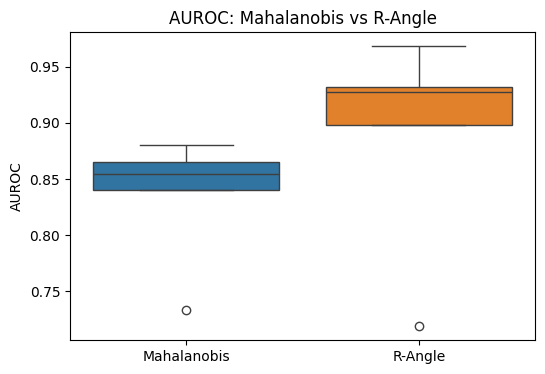

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_box = pd.DataFrame({
    "Mahalanobis": df_MAHALANOBIS["auroc"],
    "R-Angle": df_RANGLE["auroc"]
})

plt.figure(figsize=(6,4))
sns.boxplot(data=df_box)
plt.title("AUROC: Mahalanobis vs R-Angle")
plt.ylabel("AUROC")
plt.show()

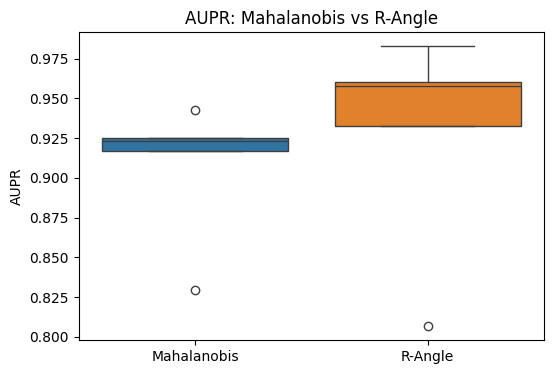

In [ ]:
df_box = pd.DataFrame({
    "Mahalanobis": df_MAHALANOBIS["aupr"],
    "R-Angle": df_RANGLE["aupr"]
})

plt.figure(figsize=(6,4))
sns.boxplot(data=df_box)
plt.title("AUPR: Mahalanobis vs R-Angle")
plt.ylabel("AUPR")
plt.show()

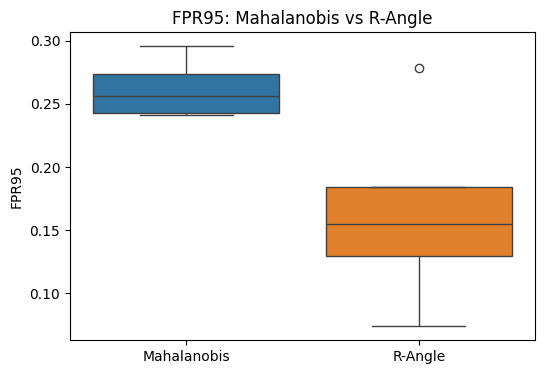

In [ ]:
df_box = pd.DataFrame({
    "Mahalanobis": df_MAHALANOBIS["fpr95"],
    "R-Angle": df_RANGLE["fpr95"]
})

plt.figure(figsize=(6,4))
sns.boxplot(data=df_box)
plt.title("FPR95: Mahalanobis vs R-Angle")
plt.ylabel("FPR95")
plt.show()

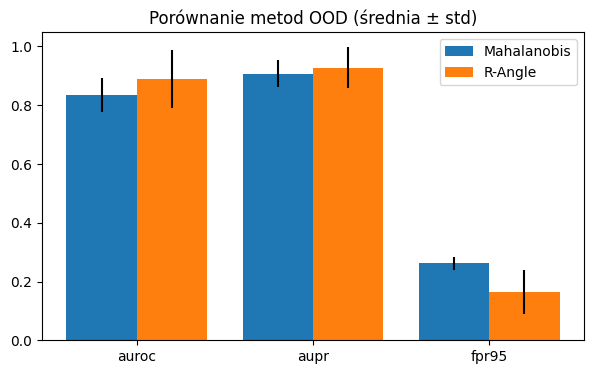

In [ ]:
metrics = ["auroc", "aupr", "fpr95"]

means_maha = df_MAHALANOBIS[metrics].mean()
std_maha = df_MAHALANOBIS[metrics].std()

means_rangle = df_RANGLE[metrics].mean()
std_rangle = df_RANGLE[metrics].std()

x = np.arange(len(metrics))

plt.figure(figsize=(7,4))

plt.bar(x - 0.2, means_maha, 0.4, yerr=std_maha, label="Mahalanobis")
plt.bar(x + 0.2, means_rangle, 0.4, yerr=std_rangle, label="R-Angle")

plt.xticks(x, metrics)
plt.legend()
plt.title("Porównanie metod OOD (średnia ± std)")
plt.show()

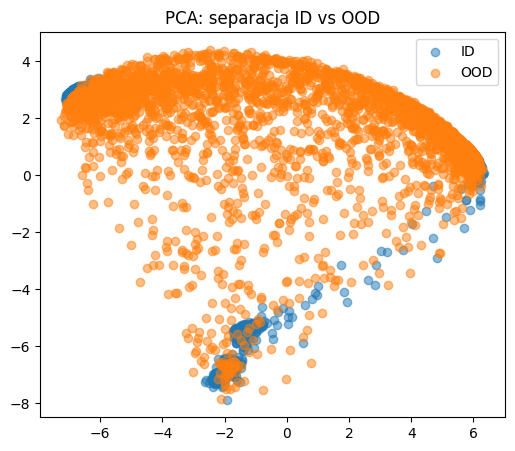

In [ ]:
emb = test_embeddings
labels = true_labels

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(test_embeddings)

is_ood = np.array([1 if l in ood_classes else 0 for l in true_labels])

plt.figure(figsize=(6,5))

plt.scatter(emb_2d[is_ood==0,0], emb_2d[is_ood==0,1], label="ID", alpha=0.5)
plt.scatter(emb_2d[is_ood==1,0], emb_2d[is_ood==1,1], label="OOD", alpha=0.5)

plt.legend()
plt.title("PCA: separacja ID vs OOD")
plt.show()

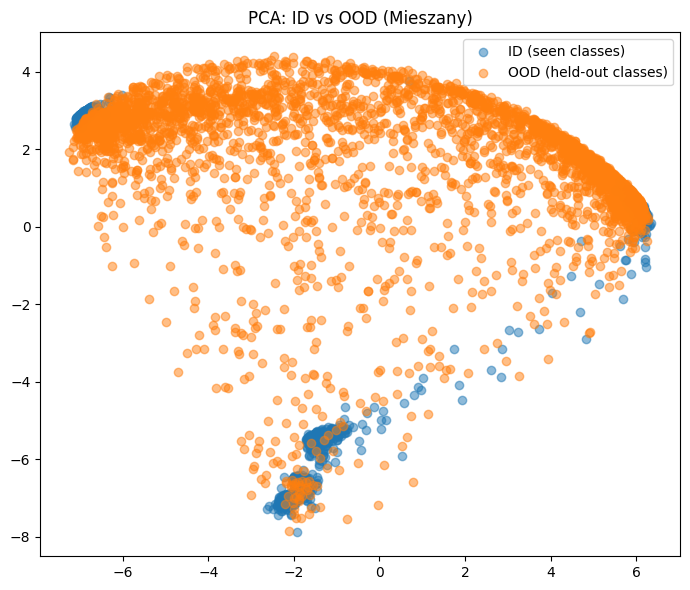

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# embeddingi testowe (już masz z pipeline)
emb = test_embeddings
labels = true_labels

# OOD = klasy wyjęte w danym foldzie
is_ood = np.array([1 if l in ood_classes else 0 for l in labels])

# PCA do 2D
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb)

plt.figure(figsize=(7,6))

# ID
plt.scatter(
    emb_2d[is_ood == 0, 0],
    emb_2d[is_ood == 0, 1],
    alpha=0.5,
    label="ID (seen classes)"
)

# OOD
plt.scatter(
    emb_2d[is_ood == 1, 0],
    emb_2d[is_ood == 1, 1],
    alpha=0.5,
    label="OOD (held-out classes)"
)

plt.title(f"PCA: ID vs OOD ({config['name']})")
plt.legend()
plt.tight_layout()

plt.savefig(f"{SAVE_PATH}/pca_id_vs_ood_{config['name']}.svg", format="svg")

plt.show()

Porównanie wszystkiego

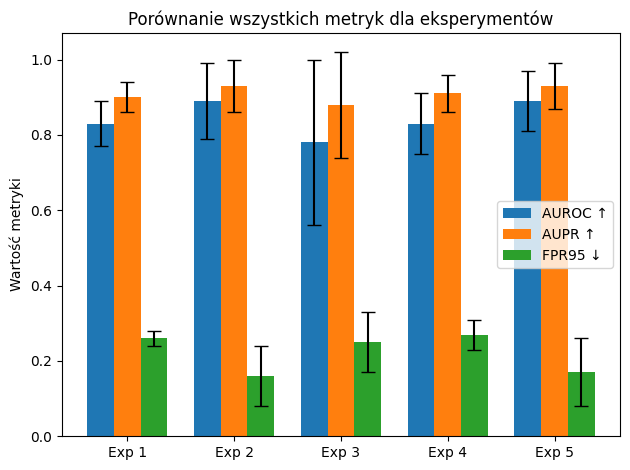

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Eksperymenty
experiments = [
    "Exp 1",
    "Exp 2",
    "Exp 3",
    "Exp 4",
    "Exp 5"
]

# Dane
auroc_mean = [0.83, 0.89, 0.78, 0.83, 0.89]
auroc_std  = [0.06, 0.10, 0.22, 0.08, 0.08]

aupr_mean = [0.90, 0.93, 0.88, 0.91, 0.93]
aupr_std  = [0.04, 0.07, 0.14, 0.05, 0.06]

fpr95_mean = [0.26, 0.16, 0.25, 0.27, 0.17]
fpr95_std  = [0.02, 0.08, 0.08, 0.04, 0.09]

x = np.arange(len(experiments))
width = 0.25  # szerokość słupków

plt.figure()

# 3 grupy słupków
plt.bar(x - width, auroc_mean, width, yerr=auroc_std, capsize=5, label="AUROC ↑")
plt.bar(x,         aupr_mean,  width, yerr=aupr_std,  capsize=5, label="AUPR ↑")
plt.bar(x + width, fpr95_mean, width, yerr=fpr95_std, capsize=5, label="FPR95 ↓")

plt.xticks(x, experiments)
plt.ylabel("Wartość metryki")
plt.title("Porównanie wszystkich metryk dla eksperymentów")
plt.legend()
plt.tight_layout()

plt.show()

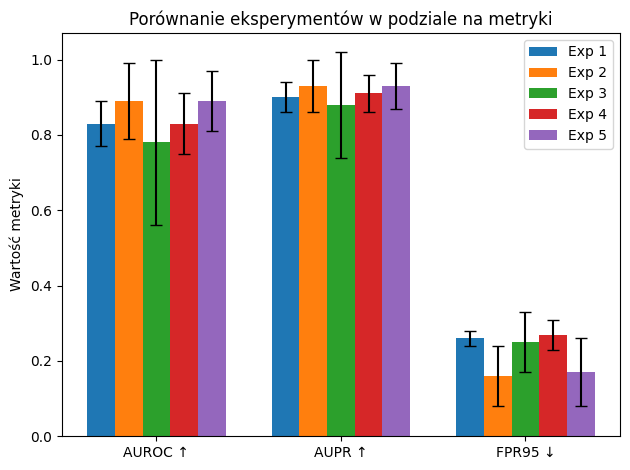

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Metryki (os X)
metrics = ["AUROC ↑", "AUPR ↑", "FPR95 ↓"]

# Dane: [Exp1, Exp2, Exp3, Exp4, Exp5]
data_mean = np.array([
    [0.83, 0.89, 0.78, 0.83, 0.89],  # AUROC
    [0.90, 0.93, 0.88, 0.91, 0.93],  # AUPR
    [0.26, 0.16, 0.25, 0.27, 0.17]   # FPR95
])

data_std = np.array([
    [0.06, 0.10, 0.22, 0.08, 0.08],
    [0.04, 0.07, 0.14, 0.05, 0.06],
    [0.02, 0.08, 0.08, 0.04, 0.09]
])

experiments = ["Exp 1", "Exp 2", "Exp 3", "Exp 4", "Exp 5"]

x = np.arange(len(metrics))
width = 0.15

plt.figure()

# rysujemy każdy eksperyment jako osobny "offset"
for i in range(len(experiments)):
    plt.bar(
        x + i * width - 2 * width,
        data_mean[:, i],
        width,
        yerr=data_std[:, i],
        capsize=4,
        label=experiments[i]
    )

plt.xticks(x, metrics)
plt.ylabel("Wartość metryki")
plt.title("Porównanie eksperymentów w podziale na metryki")
plt.legend()
plt.tight_layout()
plt.savefig(f"porownanie_eksperymentów.svg", format="svg")
plt.show()

# WALIDACJA LEAVE-ONE-OUT

In [15]:
NUM_CLASSES = 7  # Klasy od 0 do 6
fold_results_MAHALANOBIS = []

for fold_idx in range(NUM_CLASSES):

    ood_classes = [fold_idx]
    id_classes = [c for c in range(NUM_CLASSES) if c not in ood_classes]

    print(f"\n===== FOLD {fold_idx+1} =====")
    print(f"OOD class: {ood_classes}")

    id_df_full = snips_df[snips_df['label'].isin(id_classes)].copy()
    ood_df_full = snips_df[snips_df['label'].isin(ood_classes)].copy()

    train_id, test_id = train_test_split(
        id_df_full,
        test_size=0.2,
        stratify=id_df_full['label'],
        random_state=42
    )

    # TRAIN
    train_df_fold = train_id.copy()

    # TEST = ID test + pełna klasa OOD
    test_df_fold = pd.concat(
        [test_id, ood_df_full]
    ).sample(frac=1, random_state=42)

    # mapowanie etykiet tylko dla ID
    mapping = {
        old_id: new_id
        for new_id, old_id in enumerate(id_classes)
    }

    train_df_fold["mapped_label"] = (
        train_df_fold["label"].map(mapping)
    )

    train_df_fold = train_df_fold.dropna(
        subset=["mapped_label"]
    )

    train_df_fold["mapped_label"] = (
        train_df_fold["mapped_label"].astype(int)
    )

    test_df_fold = pd.concat([test_id, ood_df_full]).sample(frac=1, random_state=42)

    # mapping tylko dla train
    mapping = {old_id: new_id for new_id, old_id in enumerate(id_classes)}

    train_df_fold["mapped_label"] = train_df_fold["label"].map(mapping)

    train_df_fold = train_df_fold.dropna(subset=["mapped_label"])
    train_df_fold["mapped_label"] = train_df_fold["mapped_label"].astype(int)

    # datasets
    train_ds = Dataset.from_pandas(
        train_df_fold[['text', 'mapped_label']].rename(columns={'mapped_label': 'label'})
    ).map(tokenize_fn, batched=True)

    test_ds = Dataset.from_pandas(test_df_fold).map(tokenize_fn, batched=True)

    train_ds = train_ds.remove_columns([col for col in train_ds.column_names if col not in ["input_ids", "attention_mask", "label"]])
    test_ds = test_ds.remove_columns([col for col in test_ds.column_names if col not in ["input_ids", "attention_mask"]])

    train_ds.set_format(type='torch')
    test_ds.set_format(type='torch')

    # model
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(id_classes)
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    training_args = TrainingArguments(
        output_dir="./tmp",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        eval_strategy="no",
        save_strategy="no",
        logging_steps=100,
        report_to="none",
        fp16=True
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        data_collator=data_collator
    )
    trainer.train()

    # EMBEDDINGI
    train_embeddings = get_embeddings(model, train_ds)
    test_embeddings = get_embeddings(model, test_ds)

    train_labels = train_df_fold['mapped_label'].values
    true_labels = test_df_fold['label'].values

    # MAHALANOBIS
    class_means = []
    for c in range(len(id_classes)):
        class_means.append(train_embeddings[train_labels == c].mean(axis=0))
    class_means = np.array(class_means)

    cov = EmpiricalCovariance().fit(train_embeddings)
    precision = cov.precision_

    def mahalanobis(x, mean):
        diff = x - mean
        return np.sqrt(diff @ precision @ diff.T)

    scores = []
    diff = test_embeddings[:, None, :] - class_means[None, :, :]
    scores = np.einsum('bij,jk,bik->bi', diff, precision, diff)
    scores = np.sqrt(scores).min(axis=1)

    scores = np.array(scores)

    # METRYKI
    y_true = np.array([1 if l in ood_classes else 0 for l in true_labels])

    auroc = roc_auc_score(y_true, scores)
    precision_arr, recall_arr, _ = precision_recall_curve(y_true, scores)
    aupr = auc(recall_arr, precision_arr)

    fpr, tpr, thresholds = roc_curve(y_true, scores)
    idx = np.argmin(np.abs(tpr - 0.95))
    fpr95 = fpr[idx]

    print(f"AUROC: {auroc:.4f}")

    fold_results_MAHALANOBIS.append({
        "fold": fold_idx+1,
        "scenario": f"OOD_Class_{ood_classes[0]}",
        "auroc": auroc,
        "aupr": aupr,
        "fpr95": fpr95
    })

    print(f"Generowanie wykresu t-SNE dla Foldu {fold_idx+1}...")

    # 1. Pobieramy testowe embeddingi i prawdziwe etykiety z tego foldu
    X_fold = test_embeddings

    # Przekształcamy etykiety liczbowe na czytelne nazwy (np. ID vs OOD)
    # Zmienna 'ood_classes' jest dostępna w pętli
    y_fold_names = []
    for label in true_labels:
        if label in ood_classes:
            y_fold_names.append(f"OOD (Klasa {label})")
        else:
            y_fold_names.append(f"ID (Klasa {label})")

    # 2. Obliczamy t-SNE
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    projections = tsne.fit_transform(X_fold)

    # 3. Tworzymy wykres
    fig = px.scatter(
        x=projections[:, 0],
        y=projections[:, 1],
        color=y_fold_names,
        title=f"Przestrzeń ukryta BERT - Fold {fold_idx+1} | OOD class: {ood_classes[0]}",
        labels={'color': 'Rodzaj intencji', 'x': 'Wymiar 1', 'y': 'Wymiar 2'},
        opacity=0.8
    )

    # Pomniejszenie kropek dla lepszej czytelności
    fig.update_traces(marker=dict(size=4))

    # Wyświetlamy wykres
    # fig.show(renderer="colab")

    html_path = f"{SAVE_PATH}/mahalanobis_loo_tsne_fold_{fold_idx+1}_base.html"
    fig.write_html(html_path)
    print(f"Zapisano wykres: {html_path}")


===== FOLD 1 =====
OOD class: [0]


Map:   0%|          | 0/9953 [00:00<?, ? examples/s]

Map:   0%|          | 0/4531 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Map:   0%|          | 0/4544 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.421055
200,0.053177
300,0.054585
400,0.020103
500,0.024858
600,0.018207
700,0.013389
800,0.006092
900,0.006234


AUROC: 0.8776
Generowanie wykresu t-SNE dla Foldu 7...
Zapisano wykres: /content/drive/MyDrive/SNIPS_OOD_Project/mahalanobis_loo_tsne_fold_7_base.html


In [16]:
fold_results_RANGLE = []

NUM_CLASSES = 7

# LEAVE-ONE-OUT
for fold_idx in range(NUM_CLASSES):

    ood_classes = [fold_idx]
    id_classes = [c for c in range(NUM_CLASSES) if c not in ood_classes]

    print(f"\n===== FOLD {fold_idx+1} =====")
    print(f"OOD class: {ood_classes}")

    # PODZIAŁ DANYCH
    id_df_full = snips_df[
        snips_df['label'].isin(id_classes)
    ].copy()

    ood_df_full = snips_df[
        snips_df['label'].isin(ood_classes)
    ].copy()

    train_id, test_id = train_test_split(
        id_df_full,
        test_size=0.2,
        stratify=id_df_full['label'],
        random_state=42
    )

    # TRAIN
    train_df_fold = train_id.copy()

    # TEST = ID test + pełna klasa OOD
    test_df_fold = pd.concat(
        [test_id, ood_df_full]
    ).sample(frac=1, random_state=42)

    # MAPOWANIE ETYKIET ID
    mapping = {
        old_id: new_id
        for new_id, old_id in enumerate(id_classes)
    }

    train_df_fold['mapped_label'] = (
        train_df_fold['label'].map(mapping)
    )

    train_df_fold = train_df_fold.dropna(
        subset=['mapped_label']
    )

    train_df_fold['mapped_label'] = (
        train_df_fold['mapped_label'].astype(int)
    )

    # DATASETS
    train_ds = Dataset.from_pandas(
        train_df_fold[['text', 'mapped_label']]
        .rename(columns={'mapped_label': 'label'})
    ).map(tokenize_fn, batched=True)

    test_ds = Dataset.from_pandas(
        test_df_fold
    ).map(tokenize_fn, batched=True)

    train_ds = train_ds.remove_columns([
        col for col in train_ds.column_names
        if col not in ["input_ids", "attention_mask", "label"]
    ])

    test_ds = test_ds.remove_columns([
        col for col in test_ds.column_names
        if col not in ["input_ids", "attention_mask"]
    ])

    train_ds.set_format(type='torch')
    test_ds.set_format(type='torch')

    # MODEL
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(id_classes)
    )

    training_args = TrainingArguments(
        output_dir="./tmp",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        eval_strategy="no",
        save_strategy="no",
        logging_steps=100,
        report_to="none",
        fp16=True
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        data_collator=data_collator
    )

    trainer.train()

    # EMBEDDINGI
    train_embeddings = get_embeddings(model, train_ds)
    test_embeddings = get_embeddings(model, test_ds)

    train_labels = train_df_fold['mapped_label'].values
    true_labels = test_df_fold['label'].values

    # CENTROIDY KLAS
    class_means = []

    for c in range(len(id_classes)):
        class_means.append(
            train_embeddings[train_labels == c].mean(axis=0)
        )

    class_means = np.array(class_means)

    # R-ANGLE
    def r_angle(x, mean):
        cos_sim = cosine_similarity([x], [mean])[0][0]
        cos_sim = np.clip(cos_sim, -1.0, 1.0)
        return np.arccos(cos_sim)

    scores = []

    for x in test_embeddings:
        angles = [r_angle(x, m) for m in class_means]
        scores.append(min(angles))

    scores = np.array(scores)

    # METRYKI
    y_true = np.array([
        1 if l in ood_classes else 0
        for l in true_labels
    ])

    auroc = roc_auc_score(y_true, scores)

    precision_arr, recall_arr, _ = precision_recall_curve(
        y_true,
        scores
    )

    aupr = auc(recall_arr, precision_arr)

    fpr, tpr, thresholds = roc_curve(y_true, scores)
    idx = np.argmin(np.abs(tpr - 0.95))
    fpr95 = fpr[idx]

    print(f"AUROC: {auroc:.4f}")

    fold_results_RANGLE.append({
        "fold": fold_idx + 1,
        "scenario": f"OOD_Class_{ood_classes[0]}",
        "auroc": auroc,
        "aupr": aupr,
        "fpr95": fpr95
    })

    # ===== t-SNE =====
    print(f"Generowanie wykresu t-SNE dla Foldu {fold_idx+1}...")

    X_fold = test_embeddings

    y_fold_names = []

    for label in true_labels:
        if label in ood_classes:
            y_fold_names.append(f"OOD (Klasa {label})")
        else:
            y_fold_names.append(f"ID (Klasa {label})")

    # t-SNE
    tsne = TSNE(
        n_components=2,
        random_state=42,
        init='pca',
        learning_rate='auto'
    )

    projections = tsne.fit_transform(X_fold)

    # WYKRES
    fig = px.scatter(
        x=projections[:, 0],
        y=projections[:, 1],
        color=y_fold_names,
        title=f"Przestrzeń ukryta BERT - Fold {fold_idx+1} | OOD class: {ood_classes[0]}",
        labels={
            'color': 'Rodzaj intencji',
            'x': 'Wymiar 1',
            'y': 'Wymiar 2'
        },
        opacity=0.8
    )

    fig.update_traces(
        marker=dict(size=4)
    )

    html_path = (
        f"{SAVE_PATH}/"
        f"rangle_tsne_fold_{fold_idx+1}_loo.html"
    )

    fig.write_html(html_path)

    print(f"Zapisano wykres: {html_path}")


===== FOLD 1 =====
OOD class: [0]


Map:   0%|          | 0/9953 [00:00<?, ? examples/s]

Map:   0%|          | 0/4531 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Map:   0%|          | 0/4544 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.421055
200,0.053177
300,0.054585
400,0.020103
500,0.024858
600,0.018207
700,0.013389
800,0.006092
900,0.006234


AUROC: 0.8687
Generowanie wykresu t-SNE dla Foldu 7...
Zapisano wykres: /content/drive/MyDrive/SNIPS_OOD_Project/rangle_tsne_fold_7_loo.html


## RESULTS

In [17]:
df_MAHALANOBIS_loo = pd.DataFrame(fold_results_MAHALANOBIS)

print("\n==== FINAL MAHALANOBIS LOO ====")
print(df_MAHALANOBIS_loo)

summary_loo = {
    "Metric": ["AUROC", "AUPR", "FPR95"],
    "Mean": [
        df_MAHALANOBIS_loo["auroc"].mean(),
        df_MAHALANOBIS_loo["aupr"].mean(),
        df_MAHALANOBIS_loo["fpr95"].mean()
    ],
    "Std": [
        df_MAHALANOBIS_loo["auroc"].std(),
        df_MAHALANOBIS_loo["aupr"].std(),
        df_MAHALANOBIS_loo["fpr95"].std()
    ]
}

df_summary_loo = pd.DataFrame(summary_loo)
print(df_summary_loo)


==== FINAL MAHALANOBIS LOO ====
   fold     scenario     auroc      aupr     fpr95
0     1  OOD_Class_0  0.511926  0.488829  0.945360
1     2  OOD_Class_1  0.901773  0.881879  0.392670
2     3  OOD_Class_2  0.952924  0.942787  0.224465
3     4  OOD_Class_3  0.731385  0.690038  0.779572
4     5  OOD_Class_4  0.889184  0.845510  0.402253
5     6  OOD_Class_5  0.878095  0.872359  0.571601
6     7  OOD_Class_6  0.877648  0.857627  0.577867
  Metric      Mean       Std
0  AUROC  0.820419  0.151988
1   AUPR  0.797004  0.156299
2  FPR95  0.556255  0.245810


In [18]:
detailed_path = f"{SAVE_PATH}/wyniki_mahalanobis_loo.csv"
df_MAHALANOBIS_loo.to_csv(detailed_path, index=False)
print(f"Zapisano wyniki szczegółowe: {detailed_path}")

df_summary_loo = pd.DataFrame(summary_loo)

summary_path = f"{SAVE_PATH}/podsumowanie_mahalanobis_loo.csv"
df_summary_loo.to_csv(summary_path, index=False)

print(f"Zapisano podsumowanie statystyczne: {summary_path}")

Zapisano wyniki szczegółowe: /content/drive/MyDrive/SNIPS_OOD_Project/wyniki_mahalanobis_loo.csv
Zapisano podsumowanie statystyczne: /content/drive/MyDrive/SNIPS_OOD_Project/podsumowanie_mahalanobis_loo.csv


In [19]:
df_RANGLE_loo = pd.DataFrame(fold_results_RANGLE)

print("\n==== FINAL R-ANGLE ====")
print(df_RANGLE_loo)

summary_rangle_loo = {
    "Metric": ["AUROC", "AUPR", "FPR95"],
    "Mean": [
        df_RANGLE_loo["auroc"].mean(),
        df_RANGLE_loo["aupr"].mean(),
        df_RANGLE_loo["fpr95"].mean()
    ],
    "Std": [
        df_RANGLE_loo["auroc"].std(),
        df_RANGLE_loo["aupr"].std(),
        df_RANGLE_loo["fpr95"].std()
    ]
}

df_summary_rangle_loo = pd.DataFrame(summary_rangle_loo)
print(df_summary_rangle_loo)


==== FINAL R-ANGLE ====
   fold     scenario     auroc      aupr     fpr95
0     1  OOD_Class_0  0.638220  0.582869  0.801928
1     2  OOD_Class_1  0.959052  0.939729  0.134917
2     3  OOD_Class_2  0.966164  0.925009  0.068631
3     4  OOD_Class_3  0.886279  0.845453  0.409770
4     5  OOD_Class_4  0.970602  0.951676  0.085278
5     6  OOD_Class_5  0.946160  0.940297  0.275141
6     7  OOD_Class_6  0.868684  0.855378  0.543260
  Metric      Mean       Std
0  AUROC  0.890737  0.118376
1   AUPR  0.862916  0.130646
2  FPR95  0.331275  0.271973


In [20]:
detailed_path = f"{SAVE_PATH}/wyniki_rangle.csv"
df_RANGLE_loo.to_csv(detailed_path, index=False)
print(f"Zapisano wyniki szczegółowe: {detailed_path}")

summary_path = f"{SAVE_PATH}/podsumowanie_rangle_loo.csv"
df_summary_rangle_loo.to_csv(summary_path, index=False)

print(f"Zapisano podsumowanie statystyczne: {summary_path}")

Zapisano wyniki szczegółowe: /content/drive/MyDrive/SNIPS_OOD_Project/wyniki_rangle.csv
Zapisano podsumowanie statystyczne: /content/drive/MyDrive/SNIPS_OOD_Project/podsumowanie_rangle_loo.csv
